# Neural Approximation of Dynamic Programming Solutions: Evidence from the Rust Bus Replacement Model

## Table of Contents 

1. Introduction

2. Constructing the Classical Rust Benchmark

3. The Computational Crisis of Classical Dynamic Programming

4. Evaluating Alternative Learning Targets for Neural Approximation

5. Deep Learning Approximation of the Dynamic Decision Problem

6. Benchmark Comparison, Discussion, and Conclusions

# 1 Introduction

## 1.1 Dynamic Decision-Making and Structural Modeling

Many real-world decisions are dynamic rather than static. Current actions often affect future opportunities, constraints, and outcomes, making decisions inherently intertemporal. As a result, decision makers must evaluate not only immediate consequences but also the future implications of their choices.

Understanding such behavior requires a framework that links actions to future states. **Dynamic decision-making** therefore views behavior as the outcome of forward-looking optimization, where decisions are made with consideration of both current and future consequences.

This perspective naturally motivates **structural modeling**. Rather than describing observed behavior through statistical correlations alone, structural models seek to recover the underlying decision mechanism that generates observed choices. The objective is to explain observed behavior in terms of preferences, constraints, expectations, and optimization.

## 1.2 Dynamic Programming and Structural Estimation 

**Dynamic programming** provides a formal framework for analyzing forward-looking behavior. A dynamic decision problem can be represented through states, actions, transition dynamics, and value functions. The central idea is that the value of a decision depends not only on its immediate payoff but also on its effect on future opportunities.

The recursive structure of dynamic programming is commonly represented through the **Bellman equation**, which characterizes optimal behavior over time. Solving the Bellman equation yields the value function and the associated optimal policy.

In empirical applications, researchers typically observe actions rather than preferences or value functions. **Structural estimation** addresses this challenge by using observed behavior to recover the parameters governing the underlying decision process. Dynamic programming therefore provides the behavioral model, while structural estimation links the model to data.

## 1.3 Computational Challenges and the Motivation for Approximation

Although dynamic programming provides a powerful framework for sequential decision-making, solving dynamic models often requires repeated Bellman iterations and fixed-point computations. As the state space expands, models increasingly suffer from the **curse of dimensionality**, making exact solutions difficult to obtain.

The challenge is amplified in **structural estimation**, where the dynamic optimization problem must be solved repeatedly for different parameter values. As a result, estimation can become substantially more expensive than solving the model itself. 

These limitations have motivated increasing interest in **approximation methods**. Rather than solving dynamic models exactly, approximation-based approaches seek to represent key components of the decision problem more efficiently while preserving their essential economic structure.

## 1.4 Project Objectives and Structure 

This project investigates whether **neural-network-based approximation methods** can efficiently approximate key objects in **dynamic programming**, while preserving the **economic structure** of the original model. 

Chapter 2 constructs a classical benchmark model based on dynamic programming and structural estimation. Chapter 3 examines the computational limitations of exact solution methods and motivates approximation-based approaches. Chapter 4 evaluates alternative neural learning targets within the dynamic decision framework. Chapter 5 provides an in-depth investigation of the selected neural method. Finally, Chapter 6 compares the neural approach with the classical benchmark and discusses the broader implications for dynamic structural models.


# 2 Constructing the Classical Rust Benchmark

## 2.1 The Rust Bus Engine Replacement Problem

Rust (1987) studies the engine replacement decisions of Harold Zurcher, the maintenance superintendent of Madison Metropolitan Bus Company. The central question is when an aging bus engine should be replaced.

The decision problem can be summarized as follows:

- **State:** accumulated mileage since the last engine replacement.
- **Actions:** **Keep** the current engine or **Replace** it with a rebuilt engine.
- **Trade-off:** replacement involves a large immediate cost, while keeping an aging engine leads to increasing maintenance expenses and a higher probability of breakdown.

A key feature of the problem is that **current decisions affect future states**. If the engine is kept, mileage continues to accumulate and the engine deteriorates further. If the engine is replaced, the mileage state is reset and the replacement cycle starts again. The decision maker therefore faces a sequence of interrelated choices rather than an isolated one-period decision.

Because future operating costs depend on today's action, the problem is inherently dynamic. A static model would compare only current maintenance and replacement costs and would therefore fail to explain preventive replacement, where engines are replaced before complete failure in anticipation of future deterioration. To capture this intertemporal trade-off, Rust formulates the problem as a **dynamic optimization problem** and models the replacement decision as a **regenerative optimal stopping problem**.

This framework later became the canonical example of a **dynamic discrete choice (DDC) model**, providing the foundation for the structural analysis of forward-looking decision making under uncertainty.

## 2.2 The Rust Bus Engine Replacement Dataset 

### 2.2.1 Data Source

The dataset used in this project is the Rust (1987) bus engine replacement dataset distributed through the `rust-data` repository maintained by the OpenSourceEconomics community: https://github.com/OpenSourceEconomics/rust-data

The repository contains the original bus engine replacement data together with the associated preprocessing functions.

### 2.2.2 Data Preparation

The raw data are stored in the original format used for the Rust bus engine replacement model. The preprocessing functions provided in the repository transform the original records into a structured dataset suitable for analysis.

In [67]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Add the local rust-data repository to the Python path
sys.path.append("../data/rust-data")

from data.data_processing import data_reading, data_processing

The original Rust dataset is organized into several bus groups, each corresponding to a different set of buses in the Madison Metro fleet. In this project, I restrict the analysis to **bus group 4** in order to keep the empirical environment fixed across all solution methods.

In the Rust model, the condition of an engine is summarized by its accumulated mileage since the last replacement. As mileage increases, the engine becomes more likely to require maintenance and experience breakdowns, making mileage a key determinant of replacement decisions. To obtain a finite state space for dynamic programming, mileage is discretized into **5,000-mile intervals**. 

In [34]:
# Convert the original raw files into intermediate group-level pickle files.
data_reading()  

# Specify the data-processing configuration.
init_dict = { "groups": "group_4", "binsize": 5000 }

# Process the selected bus group and construct the cleaned panel dataset.
df_clean = data_processing(init_dict)
df_clean.head()

state  mileage usage  decision
Bus_ID period                               
5297   0          0   2353.0   NaN         0
       1          1   6299.0   1.0         0
       2          2  10479.0   1.0         0
       3          3  15201.0   1.0         0
       4          4  20326.0   1.0         0

The dataset contains four main variables: 
- `state`: the discretized mileage state of the bus 
- `mileage`: the observed odometer reading 
- `usage`: the mileage increment used to model state transitions
- `decision`: the observed engine replacement decision

For the `decision` variable:
- `0` = keep the current engine 
- `1` = replace the engine 

In [35]:
# Convert key variables to numeric format for analysis.
df_clean["state"] = pd.to_numeric(df_clean["state"])
df_clean["mileage"] = pd.to_numeric(df_clean["mileage"])
df_clean["usage"] = pd.to_numeric(df_clean["usage"])

# Generate descriptive statistics for all numeric variables
df_clean.describe()

,state,mileage,usage,decision
count,4329.000000,4329.000000,4292.000000,4329.000000
mean,25.395934,129454.487179,0.620923,0.007623
std,18.940754,94712.232318,0.510948,0.086986
min,0.000000,5.000000,0.000000,0.000000
25%,9.000000,47911.000000,0.000000,0.000000
50%,21.000000,109232.000000,1.000000,0.000000
75%,40.000000,203623.000000,1.000000,0.000000
max,77.000000,387282.000000,2.000000,1.000000


In [36]:
# Count the number of observations for each decision outcome.
df_clean["decision"].value_counts()

decision
0    4296
1      33
Name: count, dtype: int64

After preprocessing, the sample contains 4,329 monthly observations, 78 discretized mileage states, and 33 engine replacement events. 

## 2.3 Constructing the Dynamic Programming Model 

The objective of this section is to translate the processed dataset into the components required for dynamic programming. In the Rust framework, a dynamic decision model is characterized by a state space, an action space, transition dynamics, and a cost structure.

### 2.3.1 Constructing Transition Dynamics

Dynamic programming requires a law of motion that describes how the system evolves over time. In the Rust model, state transitions are governed by mileage accumulation.

To estimate the transition process empirically, each observation is linked to the following observation for the same bus, generating observed transitions between consecutive states.

Formally, the transition process is written as: $$P(x' \mid x,a)$$

where:
- $x \in X$ is the current state;
- $a \in A$ is the current action;
- $x'$ is the next-period state.

In the empirical implementation, the transition matrix is estimated from observed state transitions without explicitly conditioning on actions. Since engine replacement events are relatively rare in the sample, the estimated transition process primarily reflects mileage accumulation under the keep decision.

In [61]:
# Construct next-period states.
df_model = df_clean.copy()

df_model["next_state"] = (
    df_model
    .groupby(level="Bus_ID")["state"]
    .shift(-1)
)

df_transitions = df_model.dropna(subset=["next_state"]).copy()
df_transitions["next_state"] = df_transitions["next_state"].astype(int)

df_transitions[["state", "decision", "next_state"]].head()

state  decision  next_state
Bus_ID period                             
5297   0           0         0           1
       1           1         0           2
       2           2         0           3
       3           3         0           4
       4           4         0           4

The resulting dataset contains observed transitions from the current state to the next state. These transitions form the basis for estimating the transition probabilities used in the dynamic programming model.

In [62]:
# Estimate the empirical transition matrix.
transition_counts = pd.crosstab(
    df_transitions["state"],
    df_transitions["next_state"]
)

transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

transition_matrix.iloc[:10, :10]

next_state,0,1,2,3,4,5,6,7,8,9
state,,,,,,,,,,
0,0.492754,0.442029,0.065217,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.427184,0.572816,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.408696,0.591304,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.447154,0.536585,0.016260,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.462185,0.529412,0.008403,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.462810,0.528926,0.008264,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.368932,0.611650,0.019417,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.343750,0.625000,0.031250
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.367347,0.612245


Each row of the transition matrix represents a probability distribution over next-period states conditional on the current state. This matrix provides the empirical approximation of the transition process used by the model.

### 2.3.2 Specifying the Cost Structure

The transition matrix describes how the state evolves, but it does not explain how decisions are evaluated. Dynamic programming additionally requires a cost function that assigns an economic consequence to each action.

Following Rust (1987), two types of costs are considered:

- a maintenance cost associated with keeping the current engine;
- a replacement cost incurred when the engine is replaced.

The cost function can be written as $$C(x,a)$$ 

where:
- $x \in X$ is the current state;
- $a \in A$ is the current action. 

For the two available actions:
- $C(x,0)$ denotes the cost of keeping the current engine;
- $C(x,1)$ denotes the cost of replacing the engine.

Following the standard Rust benchmark specification, the cost function is parameterized as $$C(x,0)=\theta x$$ for the keep decision, and $$C(x,1)=RC$$ 

Here, $\theta$ controls how maintenance costs increase with mileage, while $RC$ denotes the fixed replacement cost. This specification captures the central economic trade-off in the Rust model: keeping the engine becomes more costly as mileage rises, while replacement requires a one-time cost but resets the engine condition.

### 2.3.3 Markov Decision Process Representation

The engine replacement problem can now be represented as a finite-state Markov Decision Process (MDP).

The model consists of four components:

- State space: mileage states;
- Action space: keep or replace;
- Transition matrix: probability of moving between states;
- Cost function: maintenance and replacement costs.

These components define the environment in which the decision maker operates. The next section introduces the Bellman equation, which determines the optimal replacement policy.

The resulting finite-state decision environment can be summarized as: $$MDP = (X, A, P, C)$$

where:
- $X$ is the finite state space;
- $A$ is the action space;
- $P$ is the transition function;
- $C$ is the cost function.

This is the object that will be used in the Bellman equation.

## 2.4 Bellman Representation of the Dynamic Programming Problem 

Once the dynamic programming model has been constructed, the next step is to determine the optimal replacement decision in each state. This requires evaluating the long-run consequences of alternative actions and identifying the action that minimizes expected discounted costs.

### 2.4.1 Bellman Equation

The Bellman equation provides the recursive representation of the decision problem. It states that the value of being in a given state is equal to the minimum of the expected discounted costs associated with all feasible actions.

In the Rust model, the decision maker compares the long-run cost of keeping the current engine with the long-run cost of replacing it. Because current decisions affect future states, the evaluation of an action must account for both immediate costs and future consequences.

Formally, the Bellman equation can be written as: $$V(x)=\min_{a\in A}\left\{C(x,a)+\beta E\left[V(x')|x,a\right]\right\}$$

where:
- $x \in X$ is the current state;
- $a \in A$ is the current action; 
- $A$ is the action space;
- $C(x,a)$ is the current-period cost function;
- $\beta \in (0,1)$ is the discount factor;
- $x'$ is the next-period state;
- $V(x)$ is the value function;
- $E[\cdot]$ denotes the expectation over future states.

Solving this fixed-point equation yields the value function, from which the optimal replacement policy can be derived.

### 2.4.2 Value Function and Action-Value Function 

The central object in dynamic programming is the value function. The value function measures the minimum expected discounted cost that can be achieved starting from a given state and following the optimal decision rule thereafter.

In the Rust model, the value function summarizes the long-run economic value of each mileage state. States associated with low future costs have lower values, while states associated with high future maintenance and replacement costs have higher values.

The Bellman equation defines the value function recursively: $$V(x)=\min_{a\in A}\left\{C(x,a)+\beta E[V(x')|x,a]\right\}$$

To evaluate individual actions, it is useful to define the action-value function. The action-value function measures the expected discounted cost of taking a particular action in a given state and then following the optimal policy thereafter.

Formally, $$Q(x,a)=C(x,a)+\beta E[V(x')|x,a]$$

The value function is obtained by selecting the action with the lowest action-value: $$V(x)=\min_{a\in A}Q(x,a)$$

Thus, the value function summarizes the optimal long-run cost associated with each state, while the action-value function evaluates the long-run consequences of specific actions.

### 2.4.3 Policy Function

The ultimate objective of dynamic programming is to determine the optimal policy. The policy function maps each state to the action that minimizes expected discounted costs.

Formally, $$\pi(x)=\arg\min_{a\in A}Q(x,a)$$

The policy function therefore provides a complete characterization of optimal replacement behavior across all mileage states.

## 2.5 Benchmark Solution of the Rust Model 

This section solves the dynamic programming problem defined in the previous sections. The objective is to obtain the benchmark solution of the Rust model: the value function, the action-value functions, and the optimal policy function.

### 2.5.1 Numerical Implementation of the Model 

The cost structure has already been specified in Section 2.3.2. The implementation below converts the model objects into numerical arrays used for value function iteration.

The rows of the transition matrix define the finite state space. The cost parameters are then used to construct the keep and replace costs for each state.

In [64]:
# Prepare state space and transition matrix.
states = transition_matrix.index.to_numpy()
P = transition_matrix.to_numpy()

n_states = len(states)

# Set benchmark model parameters.
beta = 0.95
theta = 0.1
RC = 10.0

# Construct action-specific costs.
keep_cost = theta * states
replace_cost = RC

print("Number of states:", n_states)
print("Discount factor:", beta)
print("Maintenance cost parameter:", theta)
print("Replacement cost:", RC)

Number of states: 78
Discount factor: 0.95
Maintenance cost parameter: 0.1
Replacement cost: 10.0


The numerical representation of the model consists of 78 mileage states, a discount factor of 0.95, and the benchmark cost parameters specified in the previous section. These objects provide the inputs required for value function iteration.

### 2.5.2 Solving the Bellman Equation 

The Bellman equation is solved using value function iteration. Starting from an initial guess, the Bellman operator is repeatedly applied until the value function converges.

Formally, the Bellman update is: $$V_{k+1}(x)=\min_{a\in A}\left\{C(x,a)+\beta E[V_k(x')|x,a]\right\}$$

At convergence, the value function satisfies: $$V(x)=T(V)(x)$$

In [65]:
# Solve the Bellman equation using value function iteration.
V = np.zeros(n_states)

tolerance = 1e-6
max_iter = 1000
errors = []

for iteration in range(max_iter):
    V_old = V.copy()

    # Continuation value if the engine is kept.
    continuation_keep = P @ V_old

    # Continuation value if the engine is replaced.
    continuation_replace = V_old[0]

    # Action-value functions.
    Q_keep = keep_cost + beta * continuation_keep
    Q_replace = replace_cost + beta * continuation_replace

    # Bellman update.
    V = np.minimum(Q_keep, Q_replace)

    # Convergence error.
    error = np.max(np.abs(V - V_old))
    errors.append(error)

    if error < tolerance:
        break

print("Converged after", iteration + 1, "iterations")
print("Final error:", error)

Converged after 273 iterations
Final error: 9.66358740583928e-07


The value function iteration converges after 273 iterations, with a final Bellman error below the specified tolerance level of $10^{-6}$. This confirms that the numerical solution has reached a stable fixed point.

### 2.5.3 Convergence Behavior

The convergence path shows how quickly the value function iteration reaches the Bellman fixed point. A declining error indicates that the value function becomes stable across iterations.

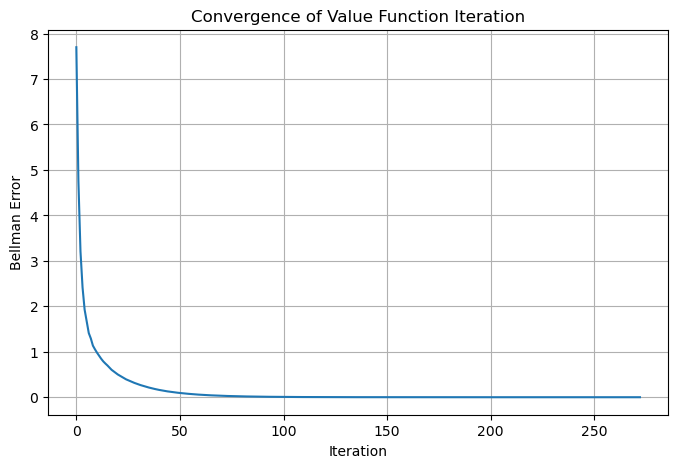

In [68]:
# Plot convergence path.
plt.figure(figsize=(8, 5))

plt.plot(errors)

plt.xlabel("Iteration")
plt.ylabel("Bellman Error")
plt.title("Convergence of Value Function Iteration")

plt.grid(True)
plt.show()

The convergence plot shows that the Bellman error declines rapidly during the first iterations and gradually approaches zero as the algorithm converges. This behavior confirms that the value function iteration procedure successfully reaches a fixed point of the Bellman operator. The stable convergence indicates that the numerical solution is reliable and that the computed value function is internally consistent with the underlying dynamic optimization problem.

### 2.5.4 Value Function

The converged value function summarizes the minimum expected discounted cost associated with each mileage state.

Because the model is written in terms of costs, higher values indicate higher long-run expected costs.

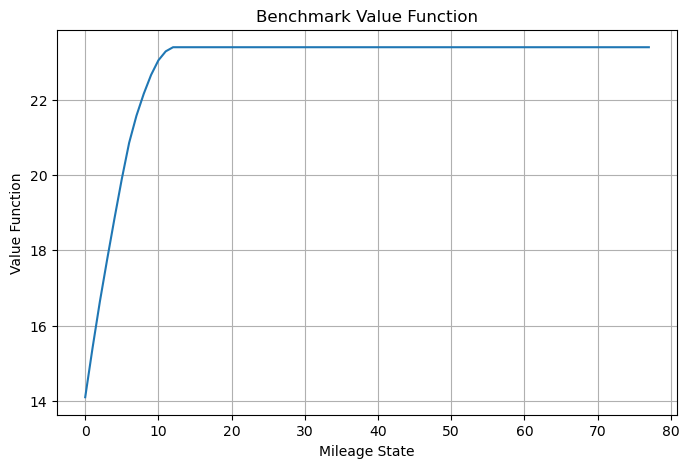

In [69]:
# Plot the value function.
plt.figure(figsize=(8, 5))

plt.plot(states, V)

plt.xlabel("Mileage State")
plt.ylabel("Value Function")
plt.title("Benchmark Value Function")

plt.grid(True)
plt.show()

The value function increases with the mileage state and becomes nearly flat at higher mileage levels. This pattern reflects the fact that operating an aging engine generates increasingly higher expected future costs. Once the engine approaches the replacement region, the option to replace limits further growth in expected costs, causing the value function to level off.

### 2.5.5 Action-Value Functions

Given the converged value function, the action-value functions evaluate the long-run cost of each action in each state.

For the keep decision: $$Q(x,0)=C(x,0)+\beta E[V(x')|x,0]$$

For the replace decision: $$Q(x,1)=C(x,1)+\beta E[V(x')|x,1]$$

Comparing these two functions determines which action is optimal in each state.

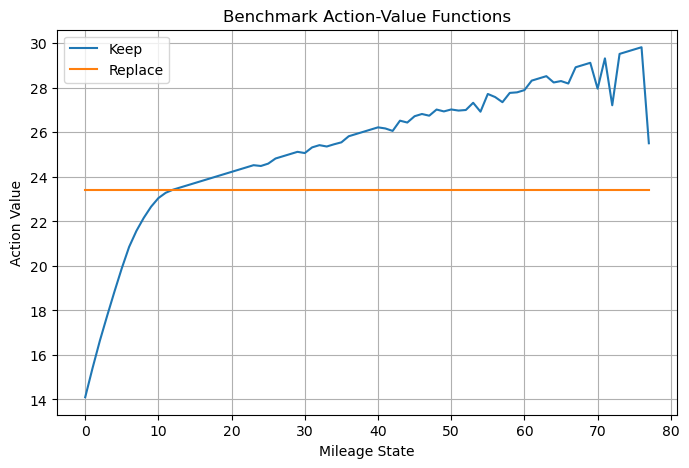

In [70]:
# Compute final action-value functions.
Q_keep = keep_cost + beta * (P @ V)

Q_replace = np.full(
    n_states,
    replace_cost + beta * V[0]
)

plt.figure(figsize=(8, 5))

plt.plot(states, Q_keep, label="Keep")
plt.plot(states, Q_replace, label="Replace")

plt.xlabel("Mileage State")
plt.ylabel("Action Value")
plt.title("Benchmark Action-Value Functions")

plt.legend()
plt.grid(True)
plt.show()

The action-value functions illustrate the trade-off between keeping and replacing the engine. The value associated with replacement remains relatively constant across states because the replacement cost is fixed. In contrast, the value of keeping the engine deteriorates as mileage increases. The intersection of the two curves identifies the replacement threshold, where the decision-maker becomes indifferent between the two actions.

### 2.5.6 Policy Function

The optimal policy is obtained by selecting the action with the lowest action-value in each state.

Formally:$$\pi(x)=\arg\min_{a\in A}Q(x,a)$$

The policy function converts the value comparison into an operational replacement rule.

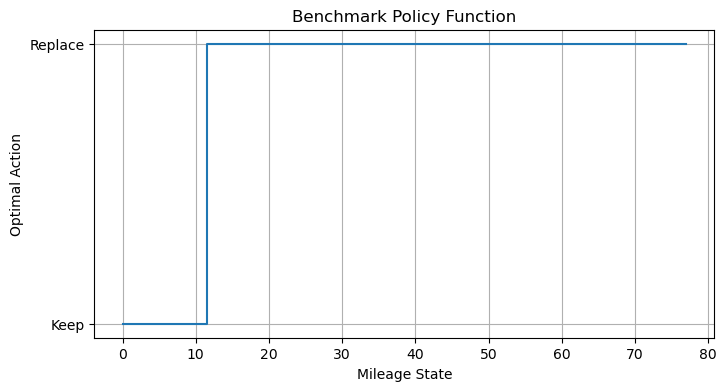

In [71]:
# Recover the optimal policy.
policy = (Q_replace < Q_keep).astype(int)

plt.figure(figsize=(8, 4))

plt.step(states, policy, where="mid")

plt.xlabel("Mileage State")
plt.ylabel("Optimal Action")
plt.yticks([0, 1], ["Keep", "Replace"])
plt.title("Benchmark Policy Function")

plt.grid(True)
plt.show()

The policy function exhibits a clear threshold structure. For lower mileage states, the optimal action is to keep the engine, while replacement becomes optimal once mileage exceeds the critical threshold. This result is consistent with the theoretical prediction of Rust (1987) and confirms that the optimal replacement problem can be characterized by a threshold policy. 

### 2.5.7 Economic Interpretation of the Benchmark Solution 

The benchmark results reveal the economic mechanism underlying Rust’s optimal replacement model. The key insight is that the replacement decision is not driven by current costs alone, but by the comparison of expected future costs associated with each action.

As engine mileage accumulates, the expected maintenance burden of keeping the current engine becomes increasingly expensive. This effect is reflected in the upward movement of the **value function** and in the deterioration of the action value associated with the keep decision. The decision-maker therefore faces a dynamic trade-off: avoid the immediate replacement cost today or incur potentially higher operating costs in the future.

The **Action-Value functions** illustrate how this trade-off evolves across states. At low mileage levels, keeping the engine remains relatively attractive because future maintenance costs are still limited. However, as mileage increases, the expected future costs of continued operation grow steadily while the replacement cost remains essentially unchanged. Eventually, the two alternatives become equally attractive, generating a critical mileage threshold.

The **policy function** shows the consequence of this trade-off. Rather than continuously adjusting behavior, the optimal strategy takes the form of a threshold rule. Below the threshold, the expected savings from postponing replacement outweigh the future maintenance burden. Above the threshold, replacing the engine immediately minimizes expected discounted costs. This result demonstrates how a complex intertemporal optimization problem can generate a simple and intuitive decision rule.

From an economic perspective, the threshold policy emerges because deterioration is cumulative while replacement resets the state of the engine. The replacement decision therefore resembles many economic decisions involving capital maintenance, equipment renewal, and durable goods management, where agents optimally tolerate gradual deterioration up to a critical point before undertaking a costly renewal action. 

## 2.6 Comparing Model Predictions with Observed Decisions 

### 2.6.1 Observed Replacement Behavior

### 2.6.2 Model-Implied Replacement Behavior

### 2.6.3 Model Fit

# 3 The Computational Crisis of Classical Dynamic Programming

This chapter discusses the main computational bottlenecks of classical dynamic programming and reviews the major methodological responses that emerged in the History.

## 3.1 Computational Bottlenecks in Classical Dynamic Programming

The computational burden of the Rust framework originates from two related but distinct sources. The first arises from solving the Bellman equation itself, while the second emerges when dynamic programming is repeatedly embedded within structural estimation. Together, these two sources form the foundation of what is often referred to as the computational crisis of classical dynamic programming.

### 3.1.1 Core Bellman Computation Bottlenecks

The Bellman equation provides the fundamental recursive representation of the Rust model. By characterizing optimal decisions through a fixed-point problem, it transforms a dynamic optimization problem into a computational problem.

The optimal value function is defined as the fixed point of the Bellman operator $$V=T(V)$$

In practice, closed-form solutions are rarely available. The value function must therefore be computed numerically through repeated applications of the Bellman operator $$V^{(k+1)}=T\!\left(V^{(k)}\right)$$ 

until convergence to $$V^{*}$$ is achieved.

While this recursive formulation provides a theoretically attractive characterization of optimal behavior, solving the Bellman equation requires repeated evaluations over the state space. As the complexity of the dynamic decision problem increases, several computational bottlenecks emerge that substantially increase the cost of exact dynamic programming.

#### Bottleneck 1 - Repeated Bellman Iteration

The Bellman equation transforms a dynamic optimization problem into a fixed-point problem. Although this formulation is conceptually simple, the fixed point is generally not available analytically and must instead be computed through repeated iteration.

The benchmark solution is obtained by repeatedly applying the Bellman operator $$V(x)=\max_{a\in\{0,1\}}\left\{u(x,a)+\beta\sum_{x'}P(x'|x,a)V(x')\right\}$$

The corresponding value iteration procedure is $$V^{(k+1)}=T(V^{(k)})$$

The computational process therefore takes the form $$V^{(0)}\rightarrow V^{(1)}\rightarrow V^{(2)}\rightarrow \cdots\rightarrow V^{*}$$

Each iteration requires evaluating the Bellman equation for every state in the state space. Consequently, the computational burden grows with both the size of the state space and the number of iterations required for convergence. Even when convergence is guaranteed, repeated Bellman iteration can become computationally expensive in large-scale dynamic decision problems. 

#### Bottleneck 2 - Curse of Dimensionality

A more fundamental challenge arises from the dimensionality of the state space itself.

Suppose the state vector contains multiple state variables $$x=(x_1,x_2,\ldots,x_d)$$

If each dimension is discretized into $$n$$ grid points, the total number of states becomes $$|S|=n^d$$

For example, $$100^1 = 100$$ $$100^2 = 10,000$$ $$100^3 = 1,000,000$$

The number of states therefore grows exponentially with the number of state variables. This phenomenon is known as the curse of dimensionality.

The importance of this bottleneck extends beyond memory requirements. Because Bellman iteration must be evaluated at every state, exponential growth in the state space directly translates into exponential growth in computational cost. As a result, exact dynamic programming quickly becomes infeasible as additional state variables are introduced. 

#### Bottleneck 3 - Memory and State Explosion

Classical dynamic programming requires explicit storage of the value function over the entire state space.

The value function can be represented as $$V=\{V(x_1),V(x_2),\ldots,V(x_{|S|})\}$$

The memory requirement therefore scales approximately as $$O(|S|)$$

In addition, dynamic programming requires storage of transition probabilities $$P=\big[P(x'|x,a)\big]$$

The number of transition elements can grow on the order of $$O(|S|^2)$$

Consequently, increases in state-space dimensionality generate not only computational challenges but also substantial storage requirements. In many practical applications, memory constraints become a limiting factor before Bellman iteration itself becomes the dominant computational cost. 

#### Bottleneck 4 - Numerical Stability and Convergence

Theoretical convergence does not necessarily imply computational efficiency.

Bellman iteration converges because the Bellman operator is a contraction mapping $$\|TV-TW\|\le\beta\|V-W\|$$

When the discount factor satisfies $$\beta \rightarrow 1$$ the fixed point exists and convergence is guaranteed.

However, as $$\beta\rightarrow1$$ the contraction becomes weaker. Successive iterations therefore generate smaller improvements, causing convergence to slow substantially.

As a result, dynamic programming problems with highly persistent future values often require many additional iterations before convergence is achieved. In large-scale environments, the resulting computational burden can become substantial even when the theoretical properties of the Bellman operator remain unchanged.


### 3.1.2 The Burden of Nested Fixed Point Estimation

The computational burden increases further when structural parameters must be estimated. In Rust's Nested Fixed Point (NFXP) framework, dynamic programming is embedded within likelihood optimization, creating an additional layer of computational complexity beyond the Bellman computation itself.

Structural estimation requires recovering the economic parameters that govern dynamic decision-making, such as replacement costs, maintenance costs, and discount factors. Unlike the solution of the Bellman equation, which assumes that the parameters are known, structural estimation treats these parameters as unknown and infers them from observed choices.

In the Rust framework, estimation proceeds by comparing observed decisions with the decisions implied by the dynamic programming model. For a given parameter vector $$\theta$$, the Bellman equation is first solved to obtain the optimal value function $$V_{\theta}(x)$$

The value function then determines optimal choice probabilities $$P(a|x;\theta)$$

which can be compared with observed replacement decisions in the data.

The likelihood function measures how well the model explains the observed choices $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$

Structural estimation therefore searches for the parameter vector that makes the observed decisions most likely under the model.

The estimation problem can be summarized as $$\hat{\theta}=\arg\max_{\theta}L(\theta)$$

The importance of this computational burden extends beyond the Rust model itself. The Nested Fixed Point algorithm became one of the foundational estimation methods in the dynamic discrete choice literature because it combines structural estimation with the exact solution of the underlying dynamic programming problem. However, this theoretical rigor comes at a substantial computational cost. Every parameter update requires a new solution of the Bellman equation, causing estimation time to increase rapidly as model complexity grows.

 The NFXP framework provides a conceptually appealing estimation strategy because likelihood evaluation is based on the exact solution of the dynamic programming problem. However, this theoretical appeal comes at a substantial computational cost.

For every candidate parameter vector $$\theta$$, the value function must first satisfy $$V_{\theta}=T_{\theta}(V_{\theta})$$ before the likelihood can be evaluated.

The resulting computational structure is therefore $$\theta\;\longrightarrow\;V_{\theta}\;\longrightarrow\;L(\theta)$$

Dynamic programming is therefore nested within likelihood optimization. Every parameter update requires a new solution of the Bellman equation, causing computational costs to increase dramatically as model complexity grows.

![](../figures/nfxp_workflow.png)

#### Bottleneck 5 - Repeated Dynamic Programming within Likelihood Optimization

The key difficulty of NFXP is that likelihood evaluation cannot be separated from the dynamic programming problem itself.

The structural likelihood can be written as $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$

However, the choice probabilities are not directly generated by the parameter vector. Instead, they are implied by the optimal solution of the dynamic programming problem.

For a given parameter vector $$\theta$$, the Bellman equation must first be solved to obtain $$V_{\theta}=T_{\theta}(V_{\theta})$$

The resulting value function determines the model-implied choice probabilities $$P(a|x;\theta)$$ which are then used to evaluate the likelihood function.

The estimation procedure therefore follows the sequence $$\theta\rightarrow V_{\theta}\rightarrow P(a|x;\theta)\rightarrow L(\theta)$$

Whenever the parameter vector changes, $$\theta^{(1)}\rightarrow V^{(1)},$$ $$\theta^{(2)}\rightarrow V^{(2)}$$ $$\theta^{(3)}\rightarrow V^{(3)}$$ the dynamic programming problem must be solved again.

The crucial point is that the computational burden arises not because solving a single Bellman equation is necessarily difficult, but because the Bellman equation must be solved repeatedly throughout the optimization procedure. Even relatively small parameter updates require a new value-function solution and a new likelihood evaluation.

As a result, the computational challenge shifts from solving one dynamic programming problem to repeatedly solving many closely related dynamic programming problems during estimation. This nested structure is the defining characteristic of the NFXP algorithm and one of the primary reasons why structural dynamic models became computationally demanding.

#### Bottleneck 6 - Computational Scaling of Structural Estimation

The computational burden of NFXP grows multiplicatively because dynamic programming and likelihood optimization are nested within one another.

Let $$N_V$$ denote the number of Bellman iterations required to solve the value function. Let $$N_{\theta}$$ denote the number of likelihood evaluations required during estimation. The overall computational burden can be approximated by $$O(N_{\theta}N_V|S|)$$

Unlike the Bellman problem alone, structural estimation must simultaneously account for all three dimensions of complexity.

An increase in the size of the state space $$|S|\uparrow$$ raises the computational cost of each Bellman iteration. An increase in model complexity often increases the number of iterations required for convergence $$N_V\uparrow$$ Similarly, a larger parameter space generally requires more likelihood evaluations during optimization $$N_{\theta}\uparrow$$

The important implication is that these sources of complexity do not operate independently. Because they interact through the nested structure of the estimation problem, computational costs can increase much faster than suggested by any individual component.

For relatively simple models, the resulting burden may remain manageable. However, as researchers introduce additional state variables, richer transition dynamics, or more flexible behavioral specifications, estimation costs can grow rapidly. In many applications, solving the dynamic programming problem is no longer the primary challenge; the challenge becomes solving it repeatedly inside a large-scale optimization routine.

This scaling problem became one of the central motivations for subsequent methodological developments. Some approaches attempted to reduce the need for repeated Bellman solutions during estimation, while others sought more efficient ways to represent and compute Bellman-based solution objects themselves.

## 3.2 Historical Responses to the Computational Crisis of Dynamic Programming 

The computational limitations of classical dynamic programming motivated a large methodological literature aimed at reducing the cost of solving and estimating dynamic decision models. Over time, two broad routes emerged. One focused on reducing the computational burden of structural estimation, while the other sought more efficient ways to approximate Bellman-based solutions within the dynamic programming framework.

![](../figures/historical_tree.png)

### 3.2.1 Econometric Route 

The econometric route seeks to reduce the computational burden of structural estimation by avoiding repeated solutions of the Bellman equation.

Under the original Nested Fixed Point framework, each parameter update requires solving the fixed point $$V_{\theta}=T_{\theta}(V_{\theta})$$ 

before evaluating the likelihood function $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$ or equivalently the log-likelihood $$\ell(\theta)=\sum_{i=1}^{N}\sum_{t=1}^{T}\log P(a_{it}\mid x_{it};\theta)$$ 

The computational objective therefore becomes $$\min\Big(\text{Number of Bellman Solves}\Big)$$ 

Rather than repeatedly solving the dynamic programming problem, econometric approaches attempt to recover structural information through alternative representations of the decision process.

#### Conditional Choice Probability Methods 

Conditional Choice Probability (CCP) methods were developed to reduce the computational burden associated with repeatedly solving the Bellman equation during structural estimation. 

The central insight is that observed choice probabilities contain information about the underlying value function. Rather than solving the dynamic programming problem for every parameter vector, CCP methods exploit the relationship between observed decisions and continuation values. 

Let$$P(a|x)=\Pr(a_t=a\mid x_t=x)$$ 

Under suitable assumptions, these probabilities can be linked to differences in choice-specific value functions $$Q(x,a)=u(x,a)+\beta E[V(x')|x,a]$$ 

Hotz and Miller (1993) showed that a one-to-one mapping exists between conditional choice probabilities and value-function differences $$P(a|x)\Longleftrightarrow Q(x,a)-Q(x,a')$$ 

As a result, portions of the dynamic programming problem can be recovered through inversion of observed choice probabilities rather than through repeated Bellman iteration. 

The main contribution of CCP methods is computational efficiency. By replacing repeated value-function solutions with probability inversion, structural estimation becomes substantially faster. 

However, the approach does not eliminate the dynamic programming structure itself. Accurate estimation still requires reliable estimates of conditional choice probabilities, and the method becomes increasingly difficult in environments with large action spaces, sparse observations, or high-dimensional state variables. 

#### Mathematical Programming Approaches 

A second branch of the econometric route reformulates the estimation problem itself rather than modifying the underlying dynamic model. The most influential example is Mathematical Programming with Equilibrium Constraints (MPEC). 

Under Rust's Nested Fixed Point algorithm, parameter estimation requires solving $$V_{\theta}=T_{\theta}(V_{\theta})$$ for every candidate parameter vector before evaluating the likelihood function $$L(\theta)$$ MPEC removes this nested structure by treating the value function as an optimization variable. 

The estimation problem becomes $$\max_{\theta,V}L(\theta,V)$$ 

subject to $$V=T_{\theta}(V)$$ 

The Bellman equation therefore appears as an equilibrium constraint rather than as an inner optimization problem. This reformulation can significantly reduce the computational cost associated with repeated Bellman solutions and allows modern nonlinear optimization algorithms to be applied directly. 

Nevertheless, the Bellman equation remains part of the estimation problem. As the state space grows, the number of equilibrium constraints increases rapidly, which can generate large-scale constrained optimization problems that remain computationally demanding. 

#### Simulation-Based Methods 

Simulation-based methods address the computational burden of evaluating expectations that arise in dynamic programming and structural estimation. 

Many dynamic decision models require the computation of expected continuation values of the form $$E[V(x')]=\int V(x')p(x'|x,a)dx'$$ 

When the state space is large or the transition process is complex, evaluating this expectation exactly can become computationally expensive. 

Simulation methods replace analytical integration with simulated draws $$E[V(x')]\approx\frac{1}{N}\sum_{i=1}^{N}V(x'_i),\qquad x'_i\sim p(x'|x,a)$$ 

The key advantage is flexibility. Simulation methods can accommodate complicated transition dynamics, latent variables, and high-dimensional stochastic processes that are difficult to integrate analytically.

However, simulation introduces sampling noise. Accuracy depends on the number of simulated observations, and computational costs may increase substantially when high precision is required. Consequently, simulation often replaces one computational problem with another: exact integration is avoided, but a large number of simulations may be needed to obtain stable estimates.

### 3.2.2 Computational Route 

The computational route emerged from a different perspective on the computational crisis of dynamic programming. Rather than reducing the burden of structural estimation, this literature focuses on reducing the cost of representing and computing Bellman-based solution objects themselves. 

Instead of avoiding the fixed-point problem $$V_{\theta}=T_{\theta}(V_{\theta})$$ the objective is to approximate the main objects generated by the dynamic programming problem more efficiently$$V_{\theta}(x),\quad Q_{\theta}(x,a),\quad\pi_{\theta}(a|x)$$ 

Here,$$V_{\theta}(x)$$ denotes the value function, $$Q_{\theta}(x,a)$$ denotes the action-value function, and$$\pi_{\theta}(a|x)$$ denotes the policy function. These objects are linked through the Bellman structure: $$Q_{\theta}(x,a)=u_{\theta}(x,a)+\beta\sum_{x'}P_{\theta}(x'|x,a)V_{\theta}(x')$$ $$V_{\theta}(x)=\max_{a}Q_{\theta}(x,a)$$ $$\pi_{\theta}(x)=\arg\max_{a}Q_{\theta}(x,a)$$ 

The central challenge is that these objects become increasingly difficult to store, compute, and evaluate as the state space expands. Consequently, the computational route focuses on finding more efficient representations of Bellman solutions rather than modifying the estimation procedure itself. 

Historically, the computational route evolved through several generations of approximation methods, reflecting a gradual shift from manually designed representations to increasingly data-driven approaches.

Importantly, these stages should not be viewed as mutually exclusive replacements. Classical approximation methods, statistical learning techniques, and deep learning approaches all remain active areas of research and continue to be used in different dynamic programming applications depending on the dimensionality, computational requirements, and interpretability objectives of the problem.

#### Classical Function Approximation 

The earliest computational responses to the Bellman equation relied on manually specified functional representations of the value function. 

Rather than storing a value for every state on a discrete grid, $$V(x)$$ the value function is approximated by a finite set of basis functions $$V(x)\approx\sum_{k=1}^{K}w_k\phi_k(x)$$ where $$\phi_k(x)$$ denotes predetermined basis functions and $$w_k$$ are coefficients to be estimated. 

Representative approaches include interpolation methods, projection methods, polynomial approximations, and other basis-function techniques. The main contribution of this approach is dimensional reduction. Instead of storing and updating values at every point in the state space, dynamic programming is performed on a relatively small set of coefficients. These methods remain widely used because they are computationally efficient, theoretically transparent, and often provide good approximations in low-dimensional settings. 

However, approximation quality depends heavily on the choice of basis functions. As state spaces become larger and more nonlinear, manually designed functional forms often become difficult to construct and may fail to capture complex value-function shapes. 

#### Learning-Based Function Approximation 

As dynamic decision models became larger and more complex, researchers increasingly moved beyond manually specified basis functions and adopted data-driven approximation methods. 

Under classical function approximation, the researcher first selects a functional representation $$V(x)\approx\sum_{k=1}^{K}w_k\phi_k(x)$$ and then estimates the coefficients $$w_k$$ 

The quality of the approximation therefore depends heavily on the choice of basis functions $$\phi_k(x)$$ 

When the underlying value function exhibits strong nonlinearities or when the state space becomes large, manually designing appropriate basis functions becomes increasingly difficult. 

Learning-based function approximation addresses this limitation by treating the representation itself as part of the learning problem. Instead of specifying the functional form in advance, the approximation is learned directly from data $$V(x)\approx f(x;\theta)$$ where $$\theta$$ denotes parameters estimated from simulated or observed data. 

The key conceptual shift is that approximation no longer relies primarily on economic intuition regarding functional forms. Instead, the representation is inferred from data and optimized according to predictive performance. 

This transition marked an important development in approximate dynamic programming. It expanded the range of functions that could be represented and reduced the dependence on manually designed basis functions. At the same time, it introduced a new challenge: the quality of the approximation now depends on the learning algorithm, the available data, and the statistical properties of the estimator. 

##### Statistical and Machine Learning Approximation 

The first generation of learning-based approximation methods relied on statistical and machine learning techniques to estimate value functions from data. 

Rather than solving the Bellman equation on a complete state grid, these methods approximate the mapping $$x\longrightarrow V(x)$$ using statistical models estimated from Bellman targets. 

A generic approximation problem can be written as $$V(x)\approx f(x;\theta)$$ where $$f(\cdot)$$ may represent a regression model, a decision tree, a kernel estimator, or another statistical learning procedure. 

Representative methods include: 
- Fitted Value Iteration - Regression-Based Approximation
- Tree Methods
- Kernel Methods

For example, fitted value iteration repeatedly constructs Bellman targets $$y_i=T(V^{(m)})(x_i)$$ and estimates $$f(x;\theta)$$ through statistical regression $$\arg\min_{\theta}\sum_{i=1}^{N}\left(y_i-f(x_i;\theta)\right)^2$$ 

Compared with classical function approximation, these methods substantially increase flexibility because the approximation is learned from data rather than imposed through predetermined basis functions.  

However, most statistical learning methods remain relatively shallow. Their performance often depends on feature engineering and the selection of appropriate model structures. As the dimensionality of the state space increases, accurately representing highly nonlinear value functions can become increasingly difficult. 

Importantly, these methods remain widely used today. In many applications they provide an attractive compromise between computational efficiency, interpretability, and approximation accuracy. 

##### Deep Learning Approximation 

Deep learning extends the learning-based approximation paradigm by employing multi-layer neural networks as flexible nonlinear function approximators. Instead of relying on manually constructed features or shallow statistical models, deep neural networks learn hierarchical representations directly from data. 

A neural network can be used to approximate different Bellman solution objects.

For example,$$V(x)\approx V_{\theta}(x)$$, $$Q(x,a)\approx Q_{\theta}(x,a)$$ or $$\pi(a|x)\approx \pi_{\theta}(a|x)$$

The specific object being approximated depends on the learning objective and the structure of the approximation method.

The key innovation is representation learning. Rather than specifying the features used for approximation, the network learns multiple layers of nonlinear transformations that are optimized jointly during training. 

Compared with earlier statistical learning methods, deep learning substantially increases representational capacity. This makes neural networks particularly attractive in dynamic decision problems characterized by high-dimensional state spaces, complex nonlinearities, and large-scale simulation environments. 

Within dynamic programming, deep learning approaches can be organized along several dimensions. 

**By Approximation Target** 

The first classification concerns which object generated by dynamic programming is approximated. 

Value Function Approximation $$V(x)\approx V_{\theta}(x)$$ 

Action-Value Function Approximation $$Q(x,a)\approx Q_{\theta}(x,a)$$ 

Policy Function Approximation $$\pi(a|x)\approx\pi_{\theta}(a|x)$$ 

These targets correspond to different components of the Bellman framework and may imply different computational trade-offs.

**By Learning Paradigm** 

A second classification concerns how learning takes place. 

In Deep Reinforcement Learning, neural networks are trained using simulated or observed trajectories $$(x_t,a_t,r_t,x_{t+1})$$ and learning is guided by Bellman-consistent targets such as $$r_t+\beta\max_{a'}Q_{\theta}(x_{t+1},a')$$ 

The objective is to learn value functions and policies directly from interactions with the environment. 

**By Equilibrium Structure** 

A third classification concerns fixed-point representations. 

Classical dynamic programming seeks a solution to $$V=T(V)$$ 

Deep Equilibrium Networks instead learn an implicit fixed-point representation $$z^*=F_\theta(z^*,x)$$ where the equilibrium state is obtained as the solution of a learned fixed-point equation rather than through explicit iterative computation.

The principal advantage of deep learning is scalability. Neural networks can represent highly complex nonlinear relationships without explicitly specifying basis functions or handcrafted features. 

However, these gains come at a cost. Approximation error remains unavoidable, convergence guarantees are generally weaker than those available in classical dynamic programming, and the resulting representations may be more difficult to interpret economically. Furthermore, performance often depends on architectural choices, optimization procedures, and hyperparameter selection. 

For these reasons, deep learning should not be viewed as a replacement for earlier approximation methods. Rather, it represents the most recent stage in a broader historical evolution of approximation techniques, complementing rather than eliminating classical and statistical approaches.

## 3.2 Historical Responses to the Computational Crisis of Dynamic Programming

The computational limitations of classical dynamic programming motivated a large methodological literature aimed at reducing the cost of solving and estimating dynamic decision models. Over time, two broad routes emerged. One focused on reducing the computational burden of structural estimation, while the other sought more efficient ways to approximate Bellman-based solutions within the dynamic programming framework.

![](../figures/historical_tree.png)

### 3.2.1 Econometric Route

The econometric route seeks to reduce the computational burden of structural estimation by avoiding repeated solutions of the Bellman equation.

Under the original Nested Fixed Point framework, each parameter update requires solving the fixed point $$V_{\theta}=T_{\theta}(V_{\theta})$$

before evaluating the likelihood function $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$

or equivalently the log-likelihood $$\ell(\theta)=\sum_{i=1}^{N}\sum_{t=1}^{T}\log P(a_{it}\mid x_{it};\theta).$$

The computational objective therefore becomes $$\min\Big(\text{Number of Bellman Solves}\Big)$$

Rather than repeatedly solving the dynamic programming problem, econometric approaches attempt to recover structural information through alternative representations of the decision process.

#### Conditional Choice Probability Methods

Conditional Choice Probability (CCP) methods were developed to reduce the computational burden associated with repeatedly solving the Bellman equation during structural estimation.

The central insight is that observed choice probabilities contain information about the underlying value function. Rather than solving the dynamic programming problem for every parameter vector, CCP methods exploit the relationship between observed decisions and continuation values.

Let$$P(a|x)=\Pr(a_t=a\mid x_t=x).$$

Under suitable assumptions, these probabilities can be linked to differences in choice-specific value functions $$Q(x,a)=u(x,a)+\beta E[V(x')|x,a]$$

Hotz and Miller (1993) showed that a one-to-one mapping exists between conditional choice probabilities and value-function differences $$P(a|x)\Longleftrightarrow Q(x,a)-Q(x,a')$$

As a result, portions of the dynamic programming problem can be recovered through inversion of observed choice probabilities rather than through repeated Bellman iteration.

The main contribution of CCP methods is computational efficiency. By replacing repeated value-function solutions with probability inversion, structural estimation becomes substantially faster.

However, the approach does not eliminate the dynamic programming structure itself. Accurate estimation still requires reliable estimates of conditional choice probabilities, and the method becomes increasingly difficult in environments with large action spaces, sparse observations, or high-dimensional state variables.

#### Mathematical Programming Approaches

A second branch of the econometric route reformulates the estimation problem itself rather than modifying the underlying dynamic model. The most influential example is Mathematical Programming with Equilibrium Constraints (MPEC).

Under Rust's Nested Fixed Point algorithm, parameter estimation requires solving $$V_{\theta}=T_{\theta}(V_{\theta})$$

for every candidate parameter vector before evaluating the likelihood function $$L(\theta)$$

MPEC removes this nested structure by treating the value function as an optimization variable.

The estimation problem becomes $$\max_{\theta,V}L(\theta,V)$$

subject to $$V=T_{\theta}(V)$$

The Bellman equation therefore appears as an equilibrium constraint rather than as an inner optimization problem. This reformulation can significantly reduce the computational cost associated with repeated Bellman solutions and allows modern nonlinear optimization algorithms to be applied directly.

Nevertheless, the Bellman equation remains part of the estimation problem. As the state space grows, the number of equilibrium constraints increases rapidly, which can generate large-scale constrained optimization problems that remain computationally demanding.

#### Simulation-Based Methods

Simulation-based methods address the computational burden of evaluating expectations that arise in dynamic programming and structural estimation.

Many dynamic decision models require the computation of expected continuation values of the form $$E[V(x')]=\int V(x')p(x'|x,a)dx'$$

When the state space is large or the transition process is complex, evaluating this expectation exactly can become computationally expensive.

Simulation methods replace analytical integration with simulated draws $$E[V(x')]\approx\frac{1}{N}\sum_{i=1}^{N}V(x'_i),\qquad x'_i\sim p(x'|x,a)$$

The key advantage is flexibility. Simulation methods can accommodate complicated transition dynamics, latent variables, and high-dimensional stochastic processes that are difficult to integrate analytically.

However, simulation introduces sampling noise. Accuracy depends on the number of simulated observations, and computational costs may increase substantially when high precision is required. Consequently, simulation often replaces one computational problem with another: exact integration is avoided, but a large number of simulations may be needed to obtain stable estimates.

### 3.2.2 Computational Route

The computational route emerged from a different perspective on the computational crisis of dynamic programming. Rather than reducing the burden of structural estimation, this literature focuses on reducing the cost of representing and computing Bellman-based solution objects themselves.

Instead of avoiding the fixed-point problem $$V_{\theta}=T_{\theta}(V_{\theta})$$

the objective is to approximate the main objects generated by the dynamic programming problem more efficiently: $$V_{\theta}(x),\quad Q_{\theta}(x,a),\quad\pi_{\theta}(a|x)$$

Here,$$V_{\theta}(x)$$ denotes the value function, $$Q_{\theta}(x,a)$$ denotes the action-value function, and$$\pi_{\theta}(a|x)$$ denotes the policy function. These objects are linked through the Bellman structure: $$Q_{\theta}(x,a)=u_{\theta}(x,a)+\beta\sum_{x'}P_{\theta}(x'|x,a)V_{\theta}(x')$$
$$V_{\theta}(x)=\max_{a}Q_{\theta}(x,a)$$
$$\pi_{\theta}(x)=\arg\max_{a}Q_{\theta}(x,a).$$

The central challenge is that these objects become increasingly difficult to store, compute, and evaluate as the state space expands. Consequently, the computational route focuses on finding more efficient representations of Bellman solutions rather than modifying the estimation procedure itself.

Historically, the computational route evolved through several generations of approximation methods, reflecting a gradual shift from manually designed representations to increasingly data-driven approaches.

Importantly, these stages should not be viewed as mutually exclusive replacements. Classical approximation methods, statistical learning techniques, and deep learning approaches all remain active areas of research and continue to be used in different dynamic programming applications depending on the dimensionality, computational requirements, and interpretability objectives of the problem.

#### Classical Function Approximation

The earliest computational responses to the Bellman equation relied on manually specified functional representations of the value function.

Rather than storing a value for every state on a discrete grid, $$V(x)$$ the value function is approximated by a finite set of basis functions $$V(x)\approx\sum_{k=1}^{K}w_k\phi_k(x)$$

where $$\phi_k(x)$$ denotes predetermined basis functions and $$w_k$$ are coefficients to be estimated.

Representative approaches include interpolation methods, projection methods, polynomial approximations, and other basis-function techniques.

The main contribution of this approach is dimensional reduction. Instead of storing and updating values at every point in the state space, dynamic programming is performed on a relatively small set of coefficients.

These methods remain widely used because they are computationally efficient, theoretically transparent, and often provide good approximations in low-dimensional settings.

However, approximation quality depends heavily on the choice of basis functions. As state spaces become larger and more nonlinear, manually designed functional forms often become difficult to construct and may fail to capture complex value-function shapes.

#### Learning-Based Function Approximation

As dynamic decision models became larger and more complex, researchers increasingly moved beyond manually specified basis functions and adopted data-driven approximation methods.

Under classical function approximation, the researcher first selects a functional representation $$V(x)\approx\sum_{k=1}^{K}w_k\phi_k(x)$$ and then estimates the coefficients $$w_k$$

The quality of the approximation therefore depends heavily on the choice of basis functions $$\phi_k(x)$$

When the underlying value function exhibits strong nonlinearities or when the state space becomes large, manually designing appropriate basis functions becomes increasingly difficult.

Learning-based function approximation addresses this limitation by treating the representation itself as part of the learning problem. Instead of specifying the functional form in advance, the approximation is learned directly from data $$V(x)\approx f(x;\theta)$$

where $$\theta$$ denotes parameters estimated from simulated or observed data.

The key conceptual shift is that approximation no longer relies primarily on economic intuition regarding functional forms. Instead, the representation is inferred from data and optimized according to predictive performance.

This transition marked an important development in approximate dynamic programming. It expanded the range of functions that could be represented and reduced the dependence on manually designed basis functions. At the same time, it introduced a new challenge: the quality of the approximation now depends on the learning algorithm, the available data, and the statistical properties of the estimator.

##### Statistical and Machine Learning Approximation

The first generation of learning-based approximation methods relied on statistical and machine learning techniques to estimate value functions from data.

Rather than solving the Bellman equation on a complete state grid, these methods approximate the mapping $$x\longrightarrow V(x)$$ using statistical models estimated from Bellman targets.

A generic approximation problem can be written as $$V(x)\approx f(x;\theta)$$

where $$f(\cdot)$$ may represent a regression model, a decision tree, a kernel estimator, or another statistical learning procedure.

Representative methods include:
- Fitted Value Iteration
- Regression-Based Approximation
- Tree Methods
- Kernel Methods

For example, fitted value iteration repeatedly constructs Bellman targets $$y_i=T(V^{(m)})(x_i)$$ and estimates $$f(x;\theta)$$ through statistical regression $$\arg\min_{\theta}\sum_{i=1}^{N}\left(y_i-f(x_i;\theta)\right)^2$$

Compared with classical function approximation, these methods substantially increase flexibility because the approximation is learned from data rather than imposed through predetermined basis functions.

However, most statistical learning methods remain relatively shallow. Their performance often depends on feature engineering and the selection of appropriate model structures. As the dimensionality of the state space increases, accurately representing highly nonlinear value functions can become increasingly difficult.

Importantly, these methods remain widely used today. In many applications they provide an attractive compromise between computational efficiency, interpretability, and approximation accuracy.

##### Deep Learning Approximation

Deep learning extends the learning-based approximation paradigm by employing multi-layer neural networks as flexible nonlinear function approximators. Instead of relying on manually constructed features or shallow statistical models, deep neural networks learn hierarchical representations directly from data.

A neural network can be used to approximate different Bellman solution objects.

For example, $$V(x)\approx V_{\theta}(x)$$, $$Q(x,a)\approx Q_{\theta}(x,a)$$ or $$\pi(a|x)\approx \pi_{\theta}(a|x)$$

The specific object being approximated depends on the learning objective and the structure of the approximation method.

The key innovation is representation learning. Rather than specifying the features used for approximation, the network learns multiple layers of nonlinear transformations that are optimized jointly during training.

Compared with earlier statistical learning methods, deep learning substantially increases representational capacity. This makes neural networks particularly attractive in dynamic decision problems characterized by high-dimensional state spaces, complex nonlinearities, and large-scale simulation environments.

Within dynamic programming, deep learning approaches can be organized along several dimensions.

**By Approximation Target**

The first classification concerns which object generated by dynamic programming is approximated.

Value Function Approximation $$V(x)\approx V_{\theta}(x)$$

Action-Value Function Approximation $$Q(x,a)\approx Q_{\theta}(x,a)$$

Policy Function Approximation $$\pi(a|x)\approx\pi_{\theta}(a|x)$$

These targets correspond to different components of the Bellman framework and may imply different computational trade-offs.

**By Learning Paradigm**

A second classification concerns how learning takes place.

In Deep Reinforcement Learning, neural networks are trained using simulated or observed trajectories $$(x_t,a_t,r_t,x_{t+1})$$ and learning is guided by Bellman-consistent targets such as $$r_t+\beta\max_{a'}Q_{\theta}(x_{t+1},a')$$

The objective is to learn value functions and policies directly from interactions with the environment.

**By Equilibrium Structure**

A third classification concerns fixed-point representations.

Classical dynamic programming seeks a solution to $$V=T(V)$$

Deep Equilibrium Networks instead learn an implicit fixed-point representation $$z^*=F_\theta(z^*,x)$$ 

where the equilibrium state is obtained as the solution of a learned fixed-point equation rather than through explicit iterative computation.

The principal advantage of deep learning is scalability. Neural networks can represent highly complex nonlinear relationships without explicitly specifying basis functions or handcrafted features.

However, these gains come at a cost. Approximation error remains unavoidable, convergence guarantees are generally weaker than those available in classical dynamic programming, and the resulting representations may be more difficult to interpret economically. Furthermore, performance often depends on architectural choices, optimization procedures, and hyperparameter selection.

For these reasons, deep learning should not be viewed as a replacement for earlier approximation methods. Rather, it represents the most recent stage in a broader historical evolution of approximation techniques, complementing rather than eliminating classical and statistical approaches.

### 3.2.2 Computational Route

The computational route accepts dynamic programming as the core framework and focuses on improving how Bellman-based solution objects are represented and computed.

Rather than avoiding the fixed-point problem $$V_{\theta}=T_{\theta}(V_{\theta})$$

the objective is to approximate the main objects generated by the dynamic programming problem more efficiently $$
V_{\theta}(x),\quad Q_{\theta}(x,a),\quad \pi_{\theta}(a|x).$$

Here, $$V_{\theta}(x)$$ denotes the value function, $$Q_{\theta}(x,a)$$ denotes the action-value function, and $$\pi_{\theta}(a|x)$$ denotes the policy function. These objects are connected by the Bellman structure
$$Q_{\theta}(x,a)=u_{\theta}(x,a)+\beta\sum_{x'}P_{\theta}(x'|x,a)V_{\theta}(x')$$
$$V_{\theta}(x)=\max_{a}Q_{\theta}(x,a)$$
$$\pi_{\theta}(x)=\arg\max_{a}Q_{\theta}(x,a)$$

The historical evolution of this route moved from manually specified functional approximations, to data-driven statistical learning methods, and more recently to deep learning approaches capable of learning high-dimensional value, policy, and equilibrium representations.

#### Classical Function Approximation

The earliest approaches approximated value functions using predefined basis functions.

Instead of storing values for every state $$V(x)\approx\sum_{k=1}^{K}w_k \phi_k(x)$$

where $$\phi_k(x)$$ denotes a set of basis functions and $$w_k$$ are unknown coefficients.

Representative approaches include:

- Interpolation
- Projection Methods
- Basis Functions
- Polynomial Approximation

The objective is to replace a large value-function grid with a compact functional representation.

#### Learning-Based Approximation

Later approaches replaced manually designed basis functions with data-driven function approximation.

The general approximation problem becomes $$V(x)\approx f(x;\theta)$$

The parameters $$\theta$$ are estimated from data rather than chosen through economic intuition.

Representative approaches include:

- Fitted Value Iteration
- Regression-Based Approximation
- Tree Methods
- Kernel Methods

These methods increase flexibility and reduce dependence on manually specified functional forms.

#### Deep Learning Approximation

Modern approaches employ neural networks as highly flexible nonlinear function approximators.

Instead of specifying $$\phi_k(x)$$ the representation itself is learned from data.

A neural network approximation can be written as $$f_{\theta}(x)$$

Different approaches can be categorized along several dimensions.

**By Approximation Target**

Value Function Approximation $$V(x)\approx V_{\theta}(x)$$

Action-Value Function Approximation $$Q(x,a)\approx Q_{\theta}(x,a)$$

Policy Function Approximation $$\pi(a|x)\approx\pi_{\theta}(a|x)$$

**By Learning Paradigm**

Deep Reinforcement Learning combines value-based and policy-based learning.

Typical objectives include $$Q(x,a)\rightarrow\pi(a|x)$$ or $$V(x)\rightarrow\pi(a|x)$$

The network learns decision rules directly from interactions or simulated trajectories.

**By Equilibrium Structure**

Deep Equilibrium Networks directly learn fixed points of nonlinear systems.

The equilibrium condition is written as $$F(z,x)$$

Rather than explicitly unrolling many iterations, the network learns the equilibrium representation itself.

#### Advantages

The computational route offers several important advantages.

- Directly addresses Bellman computation bottlenecks.
- Scales more effectively to large state spaces.
- Avoids explicit storage of large grids.
- Provides flexible nonlinear approximations.
- Can exploit modern machine learning algorithms and hardware.

#### Limitations

The computational route also introduces new challenges.

- Approximation error is unavoidable.
Convergence guarantees are often weaker than exact dynamic programming.
Neural-network solutions may be difficult to interpret economically.
Training procedures can be unstable.
Performance may depend heavily on architecture and hyperparameter choices.

## 3.2 Historical Responses to the Computational Crisis of Dynamic Programming

The computational challenges of Bellman iteration and NFXP estimation motivated the development of alternative solution strategies. Broadly speaking, the literature evolved along two major routes.

# 4 Evaluating Alternative Learning Targets for Neural Approximation 

# 5 Deep Learning Approximation of the Dynamic Decision Problem

# 6 Benchmark Comparison, Discussion, and Conclusions